## Connecting to NAS steps
Finder > cmd + K > connect

In [1]:
#import data
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import date

/opt/miniconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


In [3]:
exp_name = '20250715C'
datafile_name = 'data016'

In [4]:
#ra.reload_experiment_data(exp_name)

In [5]:
pipe = ra.create_mea_pipeline(exp_name, datafile_name, typing_file = 'dragos_kilosort2.5.classification.txt')

[2026-06-29 12:42:48] DataJoint 2.2.2 connected to root@127.0.0.1:3306
Initializing StimBlock for 20250715C block 56
For Rig C 20250715C:
This could be due to PatternMode usage.
d_display will keep the min: 59.0
{'disp_type': 'LCR', 'mu_per_pixel': 3.34, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0)}
Nearest noise chunk for data016 is chunk3 with distance 127 minutes.

Initializing ResponseBlock for 20250715C block 56
Assuming there are 12 completed epochs.
Loading VCD from /Users/simontesfaye/Documents/data/analysis/20250715C/data016/kilosort2.5 ...
VCD loaded with 786 cells.

Using chunk3 for AnalysisChunk

Loading VCD from /Users/simontesfaye/Documents/data/analysis/20250715C/chunk3/kilosort2.5 ...
VCD loaded with 661 cells.


Loaded spatial maps for channels [0, 2] and 661 cells of shape (127, 203, 2)
Spatial maps have been padded to align with RF parameters.

Cluster matching 20250715C chunk3 with ObjectMotionDots ...
66.87%

In [6]:
pipe

MEAPipeline with properties:
  Stim Block and Response Block from: ObjectMotionDots
  Stim Block from datafile data016.
  Response Block from datafile data016.
  analysis_chunk: chunk3
  match_dict: with chunk3_id : ObjectMotionDots_id
  corr_dict: with chunk3_id : calculated ei correlations

array([<Axes: title={'center': 'A1, (n = 7)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'Amacrine, (n = 19)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'BT, (n = 13)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OffM, (n = 154)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OffP, (n = 54)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OffS, (n = 5)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OnM, (n = 57)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OnP, (n = 60)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'OnS, (n = 3)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'Unknown, (n = 70)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: >, <Axes: >], dtype=object)

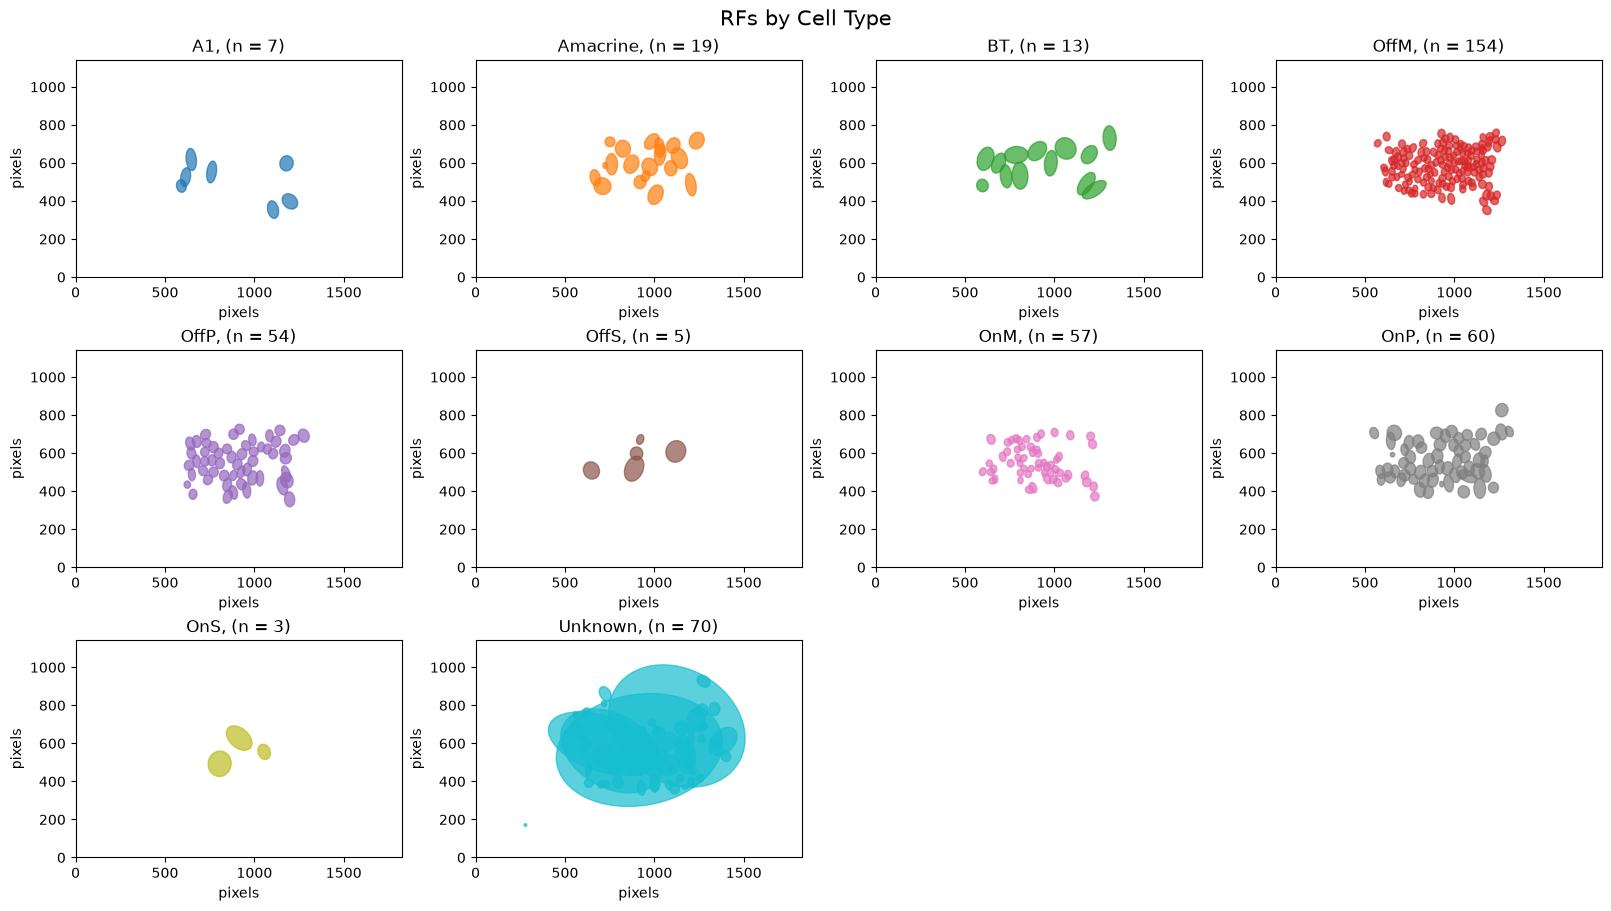

In [7]:
pipe.plot_rfs()

## Displays pipeline options

In [8]:
pipe.response_block.__dict__.keys()

dict_keys(['ss_version', 'datafile_name', 'verbose', 'b_LED', 'exp_name', 'block_id', 'h5_file', 'd_timing', 'frame_data', 'frame_sample_rate', 'd_block_summary', 'amp_sample_rate', 'vcd', 'cell_ids', 'd_EIs', 'd_EI_error', 'n_epochs', 'df_spike_times', 'protocol_name'])

## Final neat organized code for everything

In [ ]:
def create_table(pipe, parameter_name, metric_func, metric_name):
    response_block = pipe.response_block
    stim_block = pipe.stim_block
    cell_types = None

    # Get the experiment name
    exp_name = pipe.stim_block.exp_name

    # Extract the date from the experiment name
    year = int(exp_name[0:4])
    month = int(exp_name[4:6])
    day = int(exp_name[6:8])

    # Create the experiment date
    exp_date = date(year, month, day)


    # Pull spike timing data for cell types that have at least 3 cells
    spike_times = ra.get_spike_xarr(response_block, cell_types=cell_types, minimum_n=3)

    # Count the number of spikes for each cell and stimulus condition
    spike_counts = xr.apply_ufunc(len,spike_times,vectorize=True)

    # Convert xarray result into a pandas DataFrame/table
    spike_counts = spike_counts.to_dataframe(name="spike_count").reset_index()

    # Get all values for given experiement
    values = stim_block.d_epoch_block_params["parameter_name"]

    # Match each epoch to its space constant
    epoch_to_constant = dict(enumerate(values))

    # Add space constant values to the table
    spike_counts["space_constant"] = spike_counts["epoch"].map(epoch_to_constant)

    # Find smallest and largest values of whatever test automatically
    smallest_constant = min(values)
    largest_constant = max(values)

    # Average all rows that match the smallest constant
    smallest_counts = (spike_counts[spike_counts["space_constant"] == smallest_constant].groupby("cell_id")["spike_count"].mean().reset_index().rename(columns={"spike_count": "Spike count at smallest constant"}))

    # Average all rows that match the largest constant
    largest_counts = (spike_counts[spike_counts["space_constant"] == largest_constant].groupby("cell_id")["spike_count"].mean().reset_index().rename(columns={"spike_count": "Spike count at largest constant"}))

    # Combine smallest and largest spike counts into one row per cell
    summary_counts = smallest_counts.merge(largest_counts,on="cell_id",how="left")

    # Calculate normalized OMS index
    summary_counts["OMS Index"] = (summary_counts["Spike count at largest constant"]- summary_counts["Spike count at smallest constant"]
    ) / (summary_counts["Spike count at largest constant"]+ summary_counts["Spike count at smallest constant"])

    # Add experiment information
    summary_counts["Date of experiment"] = exp_date
    summary_counts["Smallest constant (microns)"] = smallest_constant
    summary_counts["Largest constant (microns)"] = largest_constant
    # summary_counts["include celll type]

    # Reorder final table
    summary_counts = summary_counts[["cell_id","Date of experiment","Smallest constant (microns)","Largest constant (microns)","Spike count at smallest constant","Spike count at largest constant","OMS Index"]]

    return summary_counts

## Potential future metric calculation code

In [11]:
def calculate_metric(low, high):
    return(high - low) / (high + low)

In [9]:
create_table(pipe)

,cell_id,Date of experiment,Smallest constant (microns),Largest constant (microns),Spike count at smallest constant,Spike count at largest constant,OMS Index
0,1,2025-07-15,50.0,1000.0,906.0,902.0,-0.002212
1,5,2025-07-15,50.0,1000.0,612.0,354.0,-0.267081
2,8,2025-07-15,50.0,1000.0,9.0,1.0,-0.800000
3,10,2025-07-15,50.0,1000.0,7.0,15.0,0.363636
4,11,2025-07-15,50.0,1000.0,13.0,1.0,-0.857143
...,...,...,...,...,...,...,...
781,1429,2025-07-15,50.0,1000.0,5.0,4.0,-0.111111
782,1431,2025-07-15,50.0,1000.0,0.0,1.0,1.000000
783,1434,2025-07-15,50.0,1000.0,0.0,0.0,NaN
784,1439,2025-07-15,50.0,1000.0,65.0,128.0,0.326425


In [10]:
summary_counts = create_table(pipe)

In [11]:
summary_counts = pd.DataFrame(summary_counts)

array([[<Axes: title={'center': 'OMS Index'}>]], dtype=object)

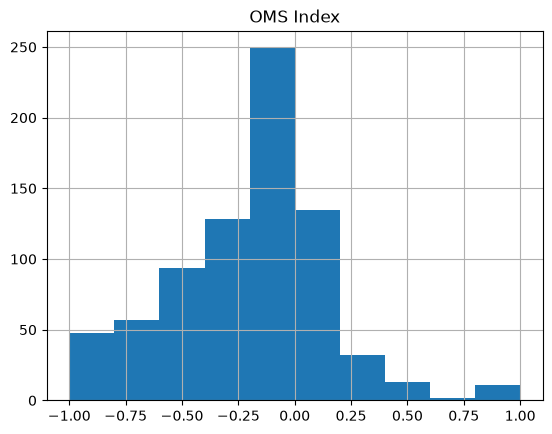

In [12]:
summary_counts.hist(column="OMS Index")

In [13]:
# Get the experiment name
exp_name = pipe.stim_block.exp_name

# Extract the date from the experiment name
year = int(exp_name[0:4])
month = int(exp_name[4:6])
day = int(exp_name[6:8])

# Create the experiment date
exp_date = date(year, month, day)

# Add the date to the final table
summary_counts["Date of experiment"] = exp_date

print(exp_date)


2025-07-15
